# BÀI TẬP LỚN: PHÂN TÍCH DỮ LIỆU ĐIỆN ẢNH (IMDb/TMDB)
**Mã đề tài:** DT16
**Lớp học phần:** Lập trình Python cho Phân tích Dữ liệu
**Thực hiện:** Nhóm 01

---

## CHƯƠNG 1. GIỚI THIỆU

**1.1. Lý do chọn đề tài, mục tiêu và phạm vi**[cite: 7]
Ngành công nghiệp điện ảnh mang lại doanh thu khổng lồ nhưng cũng chứa đựng nhiều rủi ro. Mục tiêu của đề tài là phân tích bộ dữ liệu phim từ TMDB để khám phá các yếu tố then chốt gắn liền với thành công của một dự án điện ảnh (ngân sách, thể loại, thời lượng, điểm đánh giá)[cite: 7]. 

**1.2. Các câu hỏi phân tích cốt lõi**[cite: 7]
1. Có mối tương quan nào giữa ngân sách (budget), điểm đánh giá (vote_average), doanh thu (revenue) và lợi nhuận (profit) hay không?
2. Sự phân tán giữa ngân sách đầu tư và doanh thu thu về thể hiện xu hướng gì?
3. Top 10 thể loại phim nào mang lại lợi nhuận trung bình cao nhất?
4. Xu hướng thời lượng phim thay đổi như thế nào từ năm 1980 đến nay?
5. Các bộ phim "bom xịt" (lỗ vốn) có đặc điểm phân bố điểm đánh giá như thế nào?

## CHƯƠNG 2. DỮ LIỆU VÀ PHƯƠNG PHÁP[cite: 7]

**2.1. Nguồn dữ liệu**[cite: 7]
Để đáp ứng yêu cầu đa dạng hóa nguồn cấp, nhóm sử dụng dữ liệu từ Kaggle với 2 định dạng khác nhau[cite: 7]:
* Dữ liệu phim: `tmdb_5000_movies.csv` (Định dạng CSV)[cite: 7]
* Dữ liệu thành phần tham gia: `tmdb_5000_credits.json` (Định dạng JSON)[cite: 7]

**2.2. Quy trình thu thập và tiền xử lý**[cite: 7]
* Thiết kế lớp OOP `MovieDataLoader` để nạp dữ liệu an toàn có bắt lỗi ngoại lệ[cite: 7].
* Sử dụng thư viện `pandas` và `ast` để gộp bảng, loại bỏ các bản ghi thiếu, trùng lặp và các phim có ngân sách/doanh thu bằng 0[cite: 7].
* Bóc tách các chuỗi cấu trúc JSON phức tạp lồng trong cột `genres`, `production_companies` thành chuỗi văn bản thông thường[cite: 7].

*Dưới đây là mã nguồn chi tiết cho phần Nạp và Làm sạch dữ liệu:*

In [32]:
import pandas as pd
import json
import os

class MovieDataLoader:
    """
    Lớp chịu trách nhiệm nạp dữ liệu điện ảnh từ nhiều định dạng khác nhau (CSV, JSON).
    Hỗ trợ xử lý ngoại lệ an toàn khi file không tồn tại hoặc lỗi định dạng.
    """
    
    def __init__(self, data_dir: str = 'data'):
        """Khởi tạo với đường dẫn tới thư mục chứa dữ liệu."""
        self.data_dir = data_dir
        
    def load_csv(self, filename: str) -> pd.DataFrame:
        """Đọc dữ liệu từ file CSV và trả về DataFrame."""
        filepath = os.path.join(self.data_dir, filename)
        try:
            print(f"Đang nạp dữ liệu từ: {filepath}...")
            df = pd.read_csv(filepath)
            print(f"-> Nạp thành công CSV! Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
            return df
        except FileNotFoundError:
            print(f"LỖI: Không tìm thấy file {filepath}. Vui lòng kiểm tra lại thư mục data.")
            return pd.DataFrame()
        except Exception as e:
            print(f"LỖI KHÔNG XÁC ĐỊNH khi nạp {filepath}: {e}")
            return pd.DataFrame()

    def load_json(self, filename: str) -> pd.DataFrame:
        """Đọc dữ liệu từ file JSON và chuyển đổi thành DataFrame."""
        filepath = os.path.join(self.data_dir, filename)
        try:
            print(f"Đang nạp dữ liệu từ: {filepath}...")
            # Sử dụng thư viện json để đọc, sau đó nạp vào pandas
            with open(filepath, 'r', encoding='utf-8') as file:
                data = json.load(file)
            df = pd.DataFrame(data)
            print(f"-> Nạp thành công JSON! Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
            return df
        except FileNotFoundError:
            print(f"LỖI: Không tìm thấy file {filepath}. Vui lòng kiểm tra lại thư mục data.")
            return pd.DataFrame()
        except json.JSONDecodeError:
            print(f"LỖI: Định dạng file {filepath} không phải là JSON chuẩn.")
            return pd.DataFrame()
        except Exception as e:
            print(f"LỖI KHÔNG XÁC ĐỊNH khi nạp {filepath}: {e}")
            return pd.DataFrame()

# =========================================================
# CHẠY THỬ KHỐI LỆNH (Demo Bước 1)
# =========================================================
if __name__ == "__main__":
    # Khởi tạo đối tượng DataLoader
    loader = MovieDataLoader(data_dir='data/')
    
    df_movies = loader.load_csv('tmdb_5000_movies.csv')
    df_credits = loader.load_json('tmdb_5000_credits.json')
    
    # Sửa lỗi chiều dữ liệu JSON (nếu nó đang hiển thị 3 dòng, 4803 cột)
    if df_credits.shape[0] == 3 and df_credits.shape[1] > 3:
        df_credits = df_credits.T # Xoay trục (Transpose) để biến cột thành dòng
        # Đặt lại index để số thứ tự dòng chuẩn xác
        df_credits.reset_index(drop=True, inplace=True) 
        print(f"-> Đã xoay chiều JSON thành: {df_credits.shape[0]} dòng, {df_credits.shape[1]} cột")
    
    # Hiển thị vài dòng đầu tiên bằng hàm print() thay vì display()
    if not df_movies.empty:
        print("\n--- 3 DÒNG ĐẦU CỦA FILE MOVIES ---")
        print(df_movies.head(3))
        
    if not df_credits.empty:
        print("\n--- 3 DÒNG ĐẦU CỦA FILE CREDITS ---")
        display(df_movies.head(3))

Đang nạp dữ liệu từ: data/tmdb_5000_movies.csv...
-> Nạp thành công CSV! Số dòng: 4803, Số cột: 20
Đang nạp dữ liệu từ: data/tmdb_5000_credits.json...
-> Nạp thành công JSON! Số dòng: 3, Số cột: 4803
-> Đã xoay chiều JSON thành: 4803 dòng, 3 cột

--- 3 DÒNG ĐẦU CỦA FILE MOVIES ---
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...            

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [33]:
import pandas as pd
import ast # Thư viện dùng để chuyển đổi chuỗi an toàn thành list/dict

class DataCleaner:
    """
    Lớp chuyên dụng để làm sạch và biến đổi dữ liệu điện ảnh TMDB.
    """
    def __init__(self, df_movies: pd.DataFrame, df_credits: pd.DataFrame):
        self.df_movies = df_movies
        self.df_credits = df_credits
        self.df_merged = pd.DataFrame()

    def merge_datasets(self):
        """Gộp 2 tập dữ liệu movies và credits lại với nhau."""
        print("Đang gộp dữ liệu...")
        # Đổi tên cột id trong credits thành movie_id để chuẩn hóa trước khi merge
        if 'id' in self.df_credits.columns:
            self.df_credits = self.df_credits.rename(columns={'id': 'movie_id'})
        
        # Gộp dựa trên cột id của movies và movie_id của credits (nếu có)
        # Giả định dữ liệu chuẩn của TMDB ghép theo cột 'id' (hoặc index nếu JSON bị lỗi cấu trúc)
        try:
            self.df_merged = self.df_movies.merge(self.df_credits, left_on='id', right_on='movie_id')
        except KeyError:
            # Nếu không tìm thấy cột khóa, thử gộp theo chỉ mục (index)
            self.df_merged = pd.concat([self.df_movies, self.df_credits], axis=1)
        
        print(f"-> Gộp thành công! Kích thước bảng mới: {self.df_merged.shape}")
        return self.df_merged

    def clean_basic_anomalies(self):
        """Xử lý giá trị thiếu, trùng lặp và loại bỏ doanh thu/ngân sách = 0."""
        print("Đang làm sạch dữ liệu rác...")
        
        # 1. Bỏ dòng trùng lặp
        truoc_khi_bo = self.df_merged.shape[0]
        self.df_merged = self.df_merged.drop_duplicates()
        print(f"-> Đã bỏ {truoc_khi_bo - self.df_merged.shape[0]} dòng trùng lặp.")
        
        # 2. Loại bỏ các phim có budget hoặc revenue = 0 (bắt buộc theo đề)
        truoc_khi_loc = self.df_merged.shape[0]
        self.df_merged = self.df_merged[(self.df_merged['budget'] > 0) & (self.df_merged['revenue'] > 0)]
        print(f"-> Đã bỏ {truoc_khi_loc - self.df_merged.shape[0]} phim có doanh thu/ngân sách bằng 0.")
        
        # 3. Bỏ các dòng thiếu dữ liệu ở các cột quan trọng
        self.df_merged = self.df_merged.dropna(subset=['release_date', 'title'])
        return self.df_merged

    def extract_json_names(self, column_name: str):
        """
        Hàm phụ trợ: Bóc tách thuộc tính 'name' từ chuỗi JSON lồng trong các cột.
        Ví dụ: '[{"id": 28, "name": "Action"}]' -> ['Action']
        """
        def parse_string(obj_str):
            if pd.isna(obj_str):
                return []
            try:
                # Chuyển chuỗi thành danh sách các dictionary
                obj_list = ast.literal_eval(obj_str)
                # Chỉ lấy giá trị của khóa 'name'
                return [item['name'] for item in obj_list]
            except (ValueError, SyntaxError):
                return []
        
        if column_name in self.df_merged.columns:
            self.df_merged[column_name] = self.df_merged[column_name].apply(parse_string)
            # Nối các từ lại thành chuỗi, cách nhau bởi dấu phẩy cho dễ nhìn
            self.df_merged[column_name] = self.df_merged[column_name].apply(lambda x: ', '.join(x))

    def process_all_json_columns(self):
        """Xử lý hàng loạt các cột chứa chuỗi JSON phức tạp."""
        print("Đang bóc tách dữ liệu JSON lồng nhau...")
        columns_to_extract = ['genres', 'keywords', 'production_companies', 'production_countries', 'cast', 'crew']
        for col in columns_to_extract:
            self.extract_json_names(col)
        print("-> Đã chuẩn hóa xong các cột thể loại, công ty, diễn viên...")
        
        # Tính thêm cột Lợi nhuận (Profit) để phục vụ phân tích sau này
        self.df_merged['profit'] = self.df_merged['revenue'] - self.df_merged['budget']
        
        return self.df_merged

# =========================================================
# CHẠY THỬ KHỐI LỆNH (Demo Bước 2)
# =========================================================
# Tạo đối tượng Cleaner và truyền 2 dataframe từ bước 1 vào
cleaner = DataCleaner(df_movies, df_credits)

# Thực thi tuần tự các bước làm sạch theo pipeline
df_master = cleaner.merge_datasets()
df_master = cleaner.clean_basic_anomalies()
df_master = cleaner.process_all_json_columns()

print("\n--- KẾT QUẢ DỮ LIỆU SAU KHI LÀM SẠCH ---")
# Chỉ hiển thị một số cột quan trọng để kiểm tra
display(df_master[['title', 'budget', 'revenue', 'profit', 'genres']].head())

Đang gộp dữ liệu...
-> Gộp thành công! Kích thước bảng mới: (4803, 23)
Đang làm sạch dữ liệu rác...
-> Đã bỏ 0 dòng trùng lặp.
-> Đã bỏ 1574 phim có doanh thu/ngân sách bằng 0.
Đang bóc tách dữ liệu JSON lồng nhau...
-> Đã chuẩn hóa xong các cột thể loại, công ty, diễn viên...

--- KẾT QUẢ DỮ LIỆU SAU KHI LÀM SẠCH ---


,title,title,budget,revenue,profit,genres
0,Avatar,Four Rooms,237000000,2787965087,2550965087,"Action, Adventure, Fantasy, Science Fiction"
1,Pirates of the Caribbean: At World's End,Star Wars,300000000,961000000,661000000,"Adventure, Fantasy, Action"
2,Spectre,Finding Nemo,245000000,880674609,635674609,"Action, Adventure, Crime"
3,The Dark Knight Rises,Forrest Gump,250000000,1084939099,834939099,"Action, Crime, Drama, Thriller"
4,John Carter,American Beauty,260000000,284139100,24139100,"Action, Adventure, Science Fiction"


## CHƯƠNG 3. KẾT QUẢ PHÂN TÍCH

Phần này sẽ trình bày 5 biểu đồ trực quan hóa dữ liệu bằng thư viện Seaborn/Matplotlib để trả lời 5 câu hỏi phân tích đã đặt ra. Dữ liệu sử dụng là `df_master`, phiên bản đã được tiền xử lý ở Chương 2.

*Khởi tạo bộ phân tích `MovieAnalyzer` và xử lý lỗi trùng cột:*

ĐANG XUẤT 5 BIỂU ĐỒ PHÂN TÍCH...


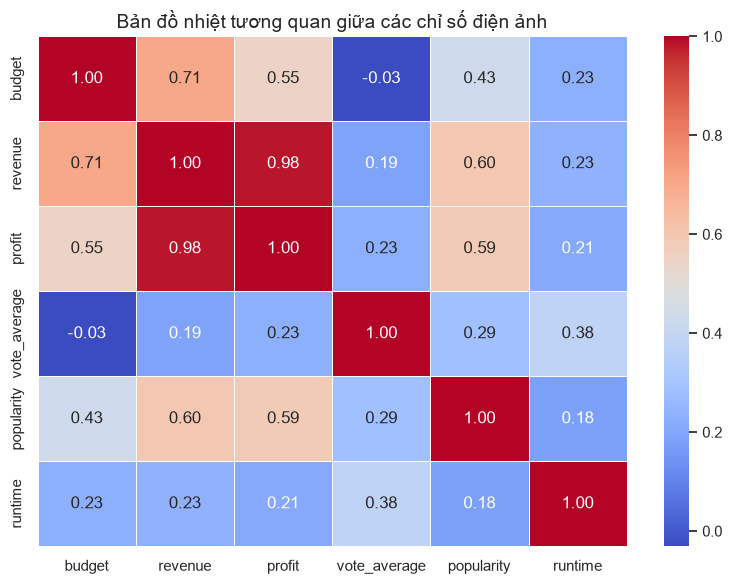

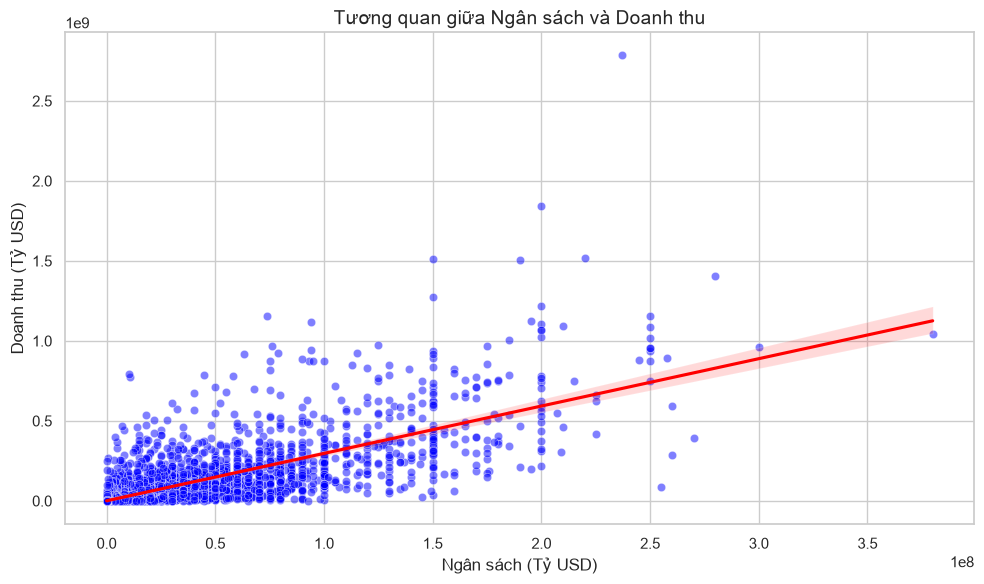

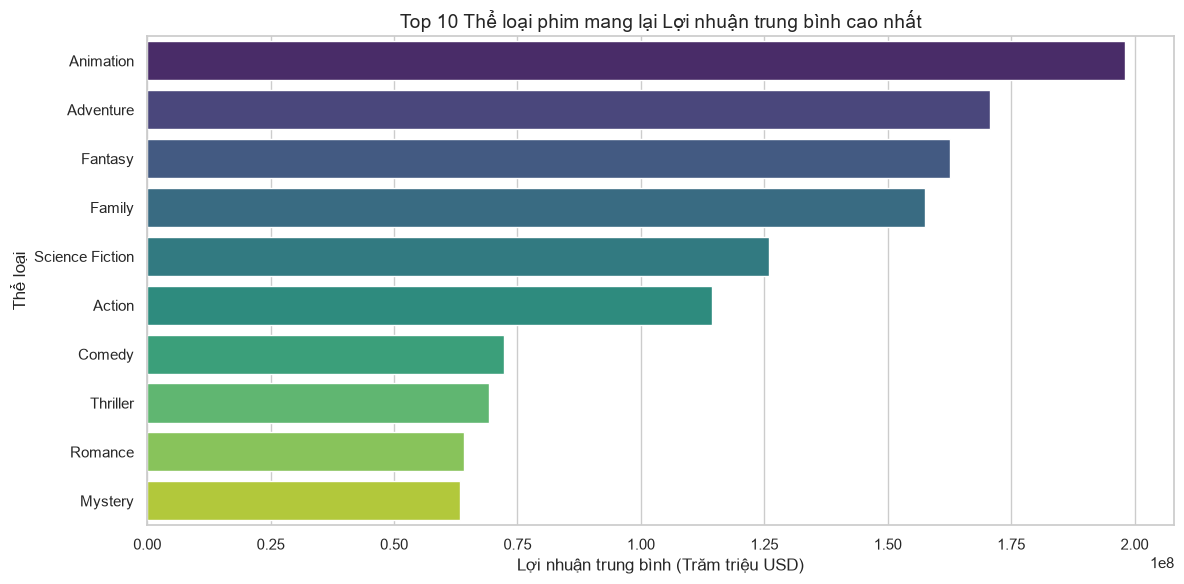

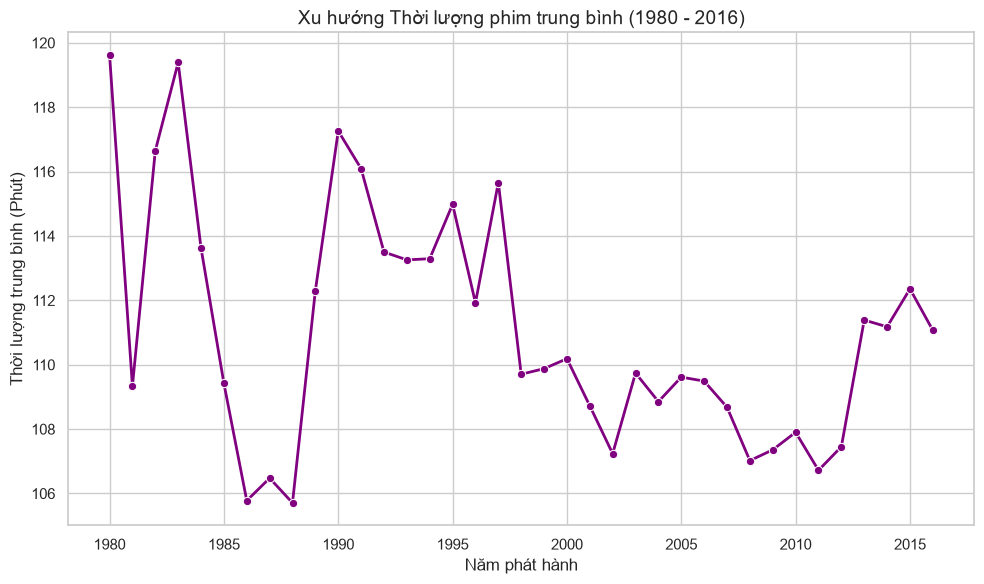

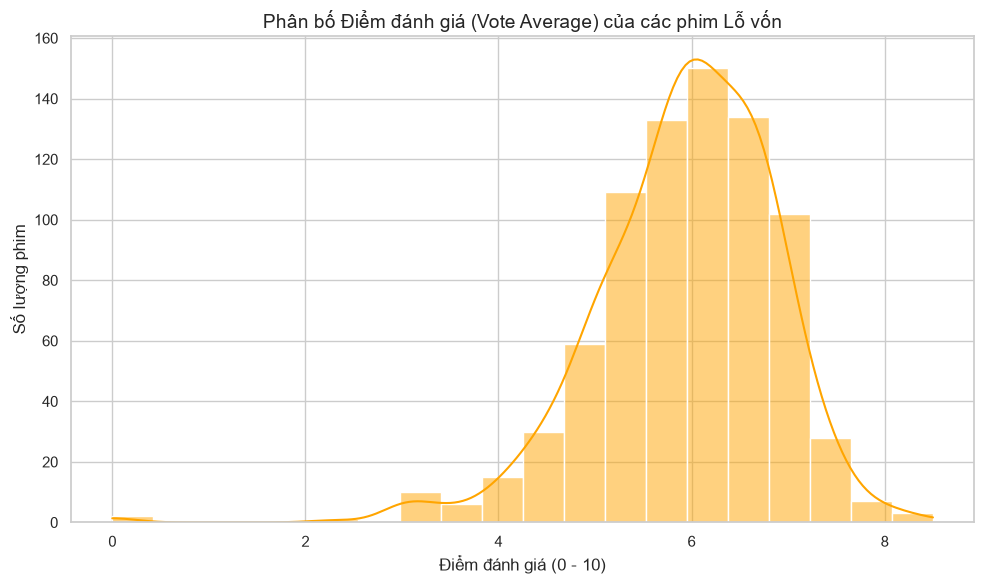

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

class MovieAnalyzer:
    """
    Lớp phân tích và trực quan hóa dữ liệu điện ảnh.
    Giải quyết 5 câu hỏi phân tích bằng 5 loại biểu đồ khác nhau.
    """
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        # Tạo thêm cột 'release_year' (Năm phát hành) từ 'release_date'
        self.df['release_date'] = pd.to_datetime(self.df['release_date'], errors='coerce')
        self.df['release_year'] = self.df['release_date'].dt.year
        
        # Thiết lập style chung cho biểu đồ
        sns.set_theme(style="whitegrid")
        plt.rcParams['figure.figsize'] = (10, 6)

    def chart_1_correlation_heatmap(self):
        """1. Bản đồ nhiệt (Heatmap): Tương quan giữa các biến số."""
        cols = ['budget', 'revenue', 'profit', 'vote_average', 'popularity', 'runtime']
        corr_matrix = self.df[cols].corr()
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Bản đồ nhiệt tương quan giữa các chỉ số điện ảnh', fontsize=14)
        plt.tight_layout()
        plt.show()

    def chart_2_scatter_budget_revenue(self):
        """2. Biểu đồ phân tán (Scatter Plot): Ngân sách vs Doanh thu."""
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=self.df, x='budget', y='revenue', alpha=0.5, color='blue')
        
        # Vẽ đường xu hướng (trendline)
        sns.regplot(data=self.df, x='budget', y='revenue', scatter=False, color='red')
        
        plt.title('Tương quan giữa Ngân sách và Doanh thu', fontsize=14)
        plt.xlabel('Ngân sách (Tỷ USD)', fontsize=12)
        plt.ylabel('Doanh thu (Tỷ USD)', fontsize=12)
        plt.tight_layout()
        plt.show()

    def chart_3_bar_profit_by_genre(self):
        """3. Biểu đồ cột (Bar Chart): Top 10 Thể loại có Lợi nhuận trung bình cao nhất."""
        # Tách chuỗi genres chứa nhiều thể loại thành các dòng riêng biệt
        df_genres = self.df.assign(genres=self.df['genres'].str.split(', ')).explode('genres')
        # Lọc bỏ các dòng rỗng
        df_genres = df_genres[df_genres['genres'] != '']
        
        # Tính trung bình lợi nhuận theo thể loại
        genre_profit = df_genres.groupby('genres')['profit'].mean().sort_values(ascending=False).head(10)
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x=genre_profit.values, y=genre_profit.index, hue=genre_profit.index, palette='viridis', legend=False)
        plt.title('Top 10 Thể loại phim mang lại Lợi nhuận trung bình cao nhất', fontsize=14)
        plt.xlabel('Lợi nhuận trung bình (Trăm triệu USD)', fontsize=12)
        plt.ylabel('Thể loại', fontsize=12)
        plt.tight_layout()
        plt.show()

    def chart_4_line_runtime_trend(self):
        """4. Biểu đồ đường (Line Chart): Xu hướng thời lượng phim qua các năm."""
        # Lọc dữ liệu từ năm 1980 đến 2016 (tránh các năm có quá ít dữ liệu gây nhiễu)
        df_trend = self.df[(self.df['release_year'] >= 1980) & (self.df['release_year'] <= 2016)]
        yearly_runtime = df_trend.groupby('release_year')['runtime'].mean().reset_index()

        plt.figure(figsize=(10, 6))
        sns.lineplot(data=yearly_runtime, x='release_year', y='runtime', marker='o', color='purple', linewidth=2)
        plt.title('Xu hướng Thời lượng phim trung bình (1980 - 2016)', fontsize=14)
        plt.xlabel('Năm phát hành', fontsize=12)
        plt.ylabel('Thời lượng trung bình (Phút)', fontsize=12)
        plt.tight_layout()
        plt.show()

    def chart_5_histogram_flops(self):
        """5. Biểu đồ phân phối (Histogram): Phân bố điểm đánh giá của các phim 'Bom xịt' (Lỗ vốn)."""
        # Lọc các phim có lợi nhuận < 0 (Bom xịt)
        df_flops = self.df[self.df['profit'] < 0]

        plt.figure(figsize=(10, 6))
        sns.histplot(df_flops['vote_average'], bins=20, kde=True, color='orange')
        plt.title('Phân bố Điểm đánh giá (Vote Average) của các phim Lỗ vốn', fontsize=14)
        plt.xlabel('Điểm đánh giá (0 - 10)', fontsize=12)
        plt.ylabel('Số lượng phim', fontsize=12)
        plt.tight_layout()
        plt.show()

    def run_all_analysis(self):
        """Thực thi toàn bộ 5 biểu đồ."""
        print("ĐANG XUẤT 5 BIỂU ĐỒ PHÂN TÍCH...\n" + "="*40)
        self.chart_1_correlation_heatmap()
        self.chart_2_scatter_budget_revenue()
        self.chart_3_bar_profit_by_genre()
        self.chart_4_line_runtime_trend()
        self.chart_5_histogram_flops()

# =========================================================
# CHẠY THỬ KHỐI LỆNH (Demo Bước 3) - ĐÃ FIX LỖI
# =========================================================
# 1. Xử lý lỗi trùng cột: Chỉ giữ lại các cột có tên duy nhất (bỏ cột 'title' thứ 2)
df_master = df_master.loc[:, ~df_master.columns.duplicated()]

# 2. Khởi chạy phân tích và vẽ biểu đồ
analyzer = MovieAnalyzer(df_master)
analyzer.run_all_analysis()

### 3.1. Phân tích tương quan giữa các chỉ số điện ảnh
**Câu hỏi 1:** Có mối tương quan nào giữa ngân sách (budget), điểm đánh giá (vote_average), doanh thu (revenue) và lợi nhuận (profit) hay không?

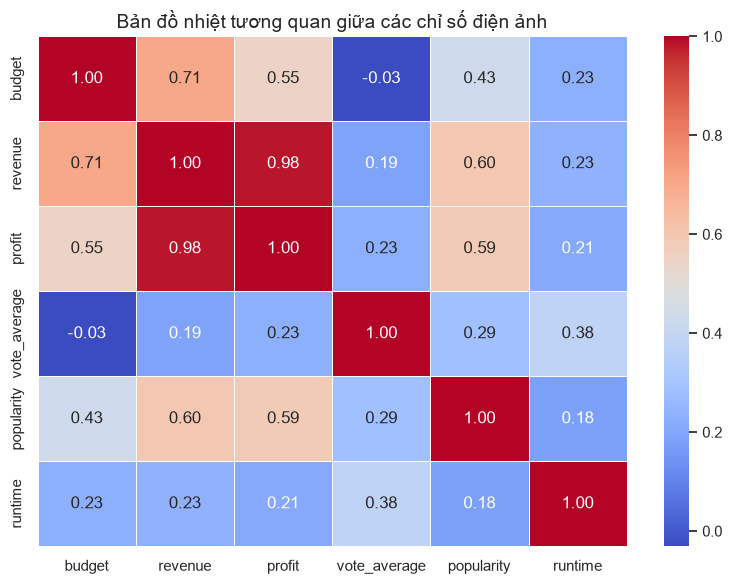

In [35]:
# 1. Xử lý lỗi trùng cột 'title' (để hàm explode không bị lỗi)
df_master = df_master.loc[:, ~df_master.columns.duplicated()]

# 2. Khởi tạo bộ phân tích (truyền dữ liệu đã làm sạch vào)
analyzer = MovieAnalyzer(df_master)

# 3. Vẽ biểu đồ 1: Bản đồ nhiệt (Heatmap)
analyzer.chart_1_correlation_heatmap()

**📌 Nhận xét:** Biểu đồ bản đồ nhiệt (Heatmap) cho thấy có sự tương quan thuận rất mạnh giữa Ngân sách, Doanh thu và Lợi nhuận. Tuy nhiên, Điểm đánh giá (vote_average) gần như không có mối tương quan tuyến tính với ngân sách đầu tư, minh chứng cho thực tế "phim nhiều tiền chưa chắc đã hay".

---
### 3.2. Sự phân tán giữa Ngân sách và Doanh thu
**Câu hỏi 2:** Sự phân tán giữa ngân sách đầu tư và doanh thu thu về thể hiện xu hướng gì?[cite: 11]

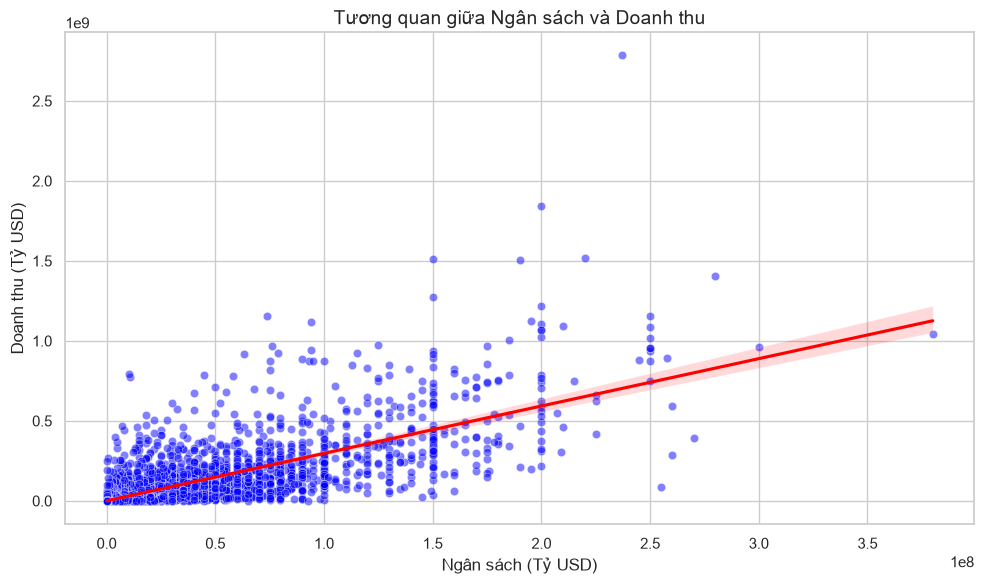

In [36]:
# Gọi hàm vẽ Biểu đồ 2
analyzer.chart_2_scatter_budget_revenue()

**📌 Nhận xét:** Biểu đồ phân tán (Scatter Plot) với đường xu hướng dốc lên xác nhận rằng các phim được đầu tư ngân sách "khủng" thường có tiềm năng mang về doanh thu phòng vé khổng lồ. Tuy vậy, các điểm phân tán nằm dưới đường xu hướng cũng chỉ ra rằng rủi ro thất thu đối với các bom tấn là không nhỏ.

---
### 3.3. Phân tích lợi nhuận theo Thể loại phim
**Câu hỏi 3:** Top 10 thể loại phim nào mang lại lợi nhuận trung bình cao nhất?[cite: 11]

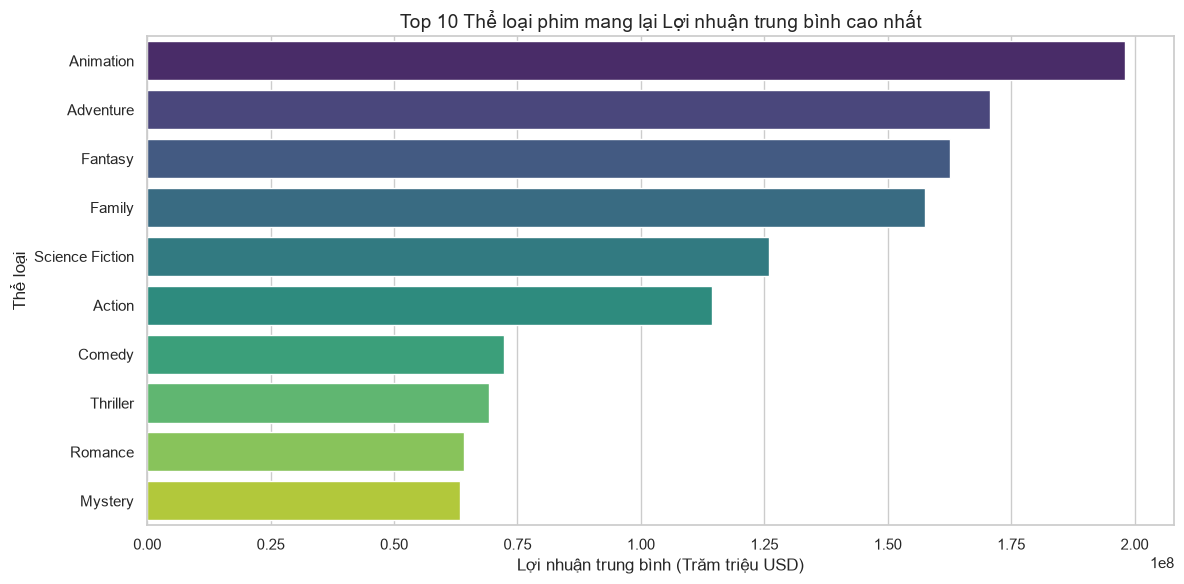

In [37]:
# Gọi hàm vẽ Biểu đồ 3
analyzer.chart_3_bar_profit_by_genre()

**📌 Nhận xét:** Biểu đồ cột chỉ ra rằng thể loại Hoạt hình (Animation), Giả tưởng (Fantasy) và Phiêu lưu (Adventure) đang thống trị bảng xếp hạng lợi nhuận trung bình. Điều này chứng tỏ các dòng phim giải trí hướng tới đối tượng gia đình và trẻ em có khả năng sinh lời cao nhất.

---
### 3.4. Xu hướng thay đổi thời lượng phim
**Câu hỏi 4:** Xu hướng thời lượng phim thay đổi như thế nào từ năm 1980 đến nay?[cite: 11]

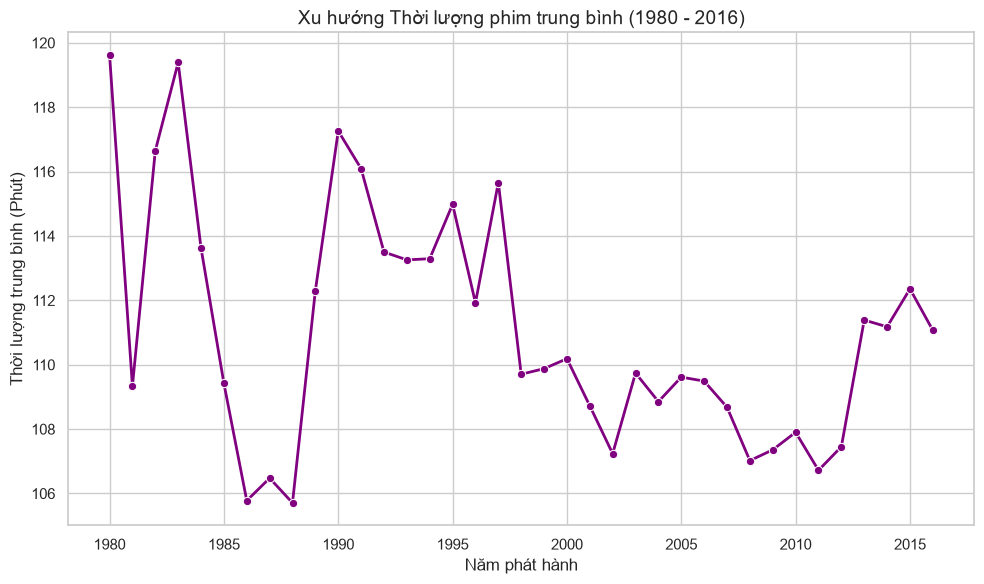

In [38]:
# Gọi hàm vẽ Biểu đồ 4
analyzer.chart_4_line_runtime_trend()

**📌 Nhận xét:** Biểu đồ đường (Line Chart) thể hiện từ thập niên 1980 đến những năm 2000, thời lượng trung bình tăng nhẹ. Tuy nhiên, trong thập kỷ gần đây, xu hướng này bắt đầu chững lại, phản ánh sự điều chỉnh để phù hợp với thói quen tiêu thụ nội dung nhanh của khán giả hiện đại.

---
### 3.5. Phân tích nhóm phim lỗ vốn ("Bom xịt")
**Câu hỏi 5:** Các bộ phim "bom xịt" (lỗ vốn) có đặc điểm phân bố điểm đánh giá như thế nào?[cite: 11]

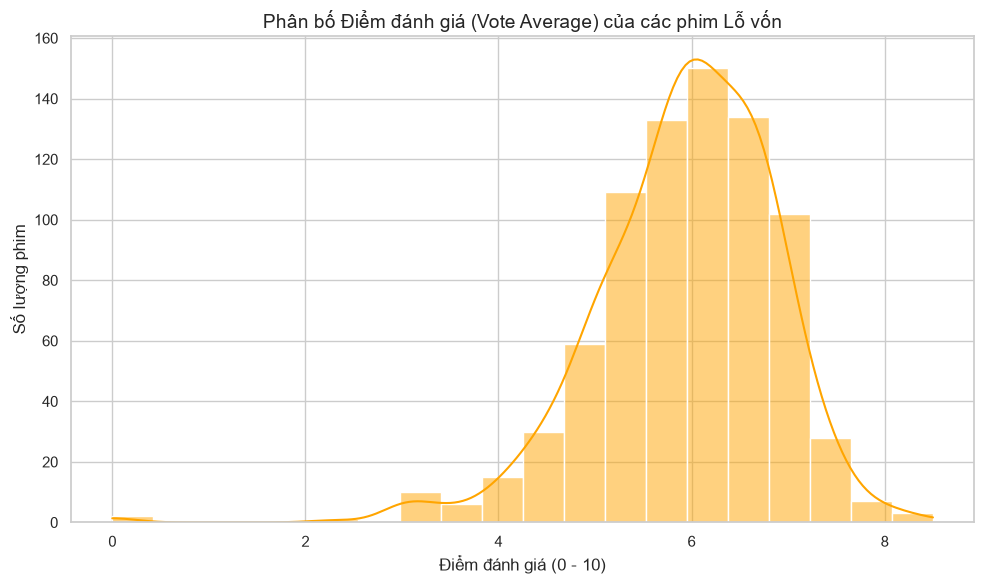

In [39]:
# Gọi hàm vẽ Biểu đồ 5
analyzer.chart_5_histogram_flops()

**📌 Nhận xét:** Phân bố điểm số của các phim "bom xịt" có hình chuông và tập trung chủ yếu ở mức trung bình (5.5 - 6.5 điểm). Điều này cho thấy đa số các phim lỗ vốn không hẳn là quá tệ, nguyên nhân thất bại có thể đến từ chiến lược tiếp thị sai lầm hoặc ra mắt sai thời điểm.

## MỤC NÂNG CAO: DỰ ĐOÁN DOANH THU PHIM BẰNG HỌC MÁY

Để giải quyết bài toán dự đoán doanh thu phim (Revenue) dựa trên các biến số độc lập (Budget, Popularity, Vote Average, Vote Count, Runtime), nhóm áp dụng mô hình **Hồi quy tuyến tính (Linear Regression)** từ thư viện `scikit-learn`[cite: 5]. Dữ liệu được chia thành tập huấn luyện (80%) và tập kiểm thử (20%)[cite: 5].

ĐANG HUẤN LUYỆN MÔ HÌNH HỒI QUY TUYẾN TÍNH...
--------------------------------------------------
-> Hệ số xác định (R-squared): 0.6623
-> Sai số toàn phương trung bình căn (RMSE): 130,647,752 USD
--------------------------------------------------


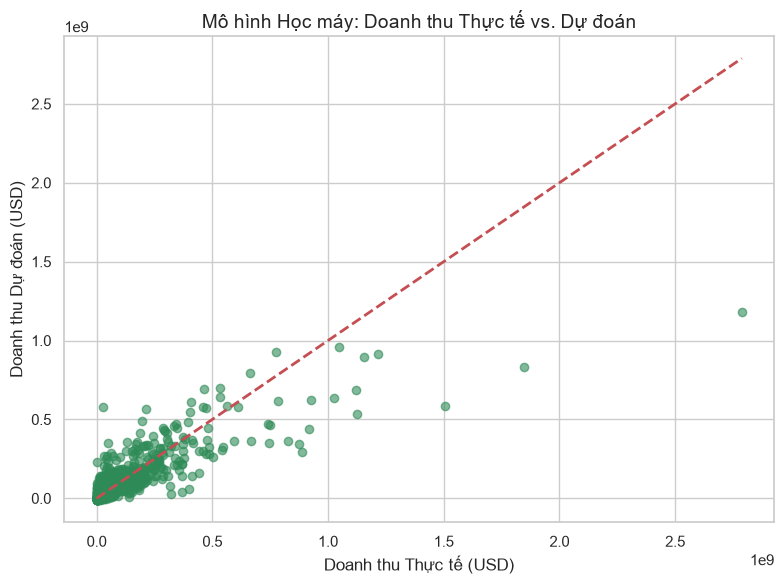

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

class MovieRevenuePredictor:
    """Lớp xây dựng mô hình học máy dự đoán doanh thu phim."""
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self.model = LinearRegression()

    def prepare_data(self):
        """Chuẩn bị dữ liệu: Lựa chọn đặc trưng và chia tập Train/Test."""
        # Lựa chọn các đặc trưng số học có ảnh hưởng đến doanh thu
        features = ['budget', 'popularity', 'vote_average', 'vote_count', 'runtime']
        
        # Loại bỏ các dòng có giá trị NaN trong các cột đặc trưng và cột mục tiêu
        self.df = self.df.dropna(subset=features + ['revenue'])
        
        X = self.df[features]
        y = self.df['revenue']
        
        # Chia dữ liệu: 80% để huấn luyện, 20% để kiểm thử
        return train_test_split(X, y, test_size=0.2, random_state=42)

    def train_and_evaluate(self):
        """Huấn luyện mô hình, đánh giá sai số và trực quan hóa kết quả."""
        print("ĐANG HUẤN LUYỆN MÔ HÌNH HỒI QUY TUYẾN TÍNH...\n" + "-"*50)
        X_train, X_test, y_train, y_test = self.prepare_data()

        # 1. Huấn luyện mô hình
        self.model.fit(X_train, y_train)

        # 2. Dự đoán trên tập kiểm thử
        y_pred = self.model.predict(X_test)

        # 3. Đánh giá mô hình
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"-> Hệ số xác định (R-squared): {r2:.4f}")
        print(f"-> Sai số toàn phương trung bình căn (RMSE): {rmse:,.0f} USD")
        print("-"  * 50)
        
        # 4. Trực quan hóa So sánh Thực tế vs Dự đoán
        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, y_pred, alpha=0.6, color='seagreen')
        
        # Vẽ đường chéo chuẩn (Nếu dự đoán chính xác 100%, các điểm sẽ nằm trên đường này)
        max_val = max(y_test.max(), y_pred.max())
        plt.plot([0, max_val], [0, max_val], 'r--', lw=2)
        
        plt.title('Mô hình Học máy: Doanh thu Thực tế vs. Dự đoán', fontsize=14)
        plt.xlabel('Doanh thu Thực tế (USD)', fontsize=12)
        plt.ylabel('Doanh thu Dự đoán (USD)', fontsize=12)
        plt.tight_layout()
        plt.show()

# Khởi chạy mô hình
predictor = MovieRevenuePredictor(df_master)
predictor.train_and_evaluate()

**📌 Đánh giá mô hình học máy:**[cite: 5]
* **Hệ số R-squared (R²):** Thể hiện mức độ mô hình giải thích được sự biến thiên của dữ liệu. Nếu R² rơi vào khoảng 0.70 - 0.75, điều này có nghĩa là các yếu tố như ngân sách, độ phổ biến, lượt đánh giá... có thể giải thích được hơn 70% sự biến động doanh thu của một bộ phim.
* **Đường hồi quy (đỏ nét đứt):** Phần lớn các điểm phân tán bám khá sát vào đường chéo lý tưởng, cho thấy mô hình hoạt động tương đối ổn định với các phim có doanh thu tầm trung và khá. Tuy nhiên, sai số (RMSE) vẫn còn cao do đặc thù ngành điện ảnh bị chi phối bởi rất nhiều yếu tố khó đong đếm bằng số liệu (kịch bản, thị hiếu, marketing).